**Author:** Christopher Millward<br>
**Date:** August 31, 2026

The purpose of this notebook is to develop a correction algorithm to "tare" the initial IMU positions.

Since the participants started each trial in the "tin soldier" position, and their arms were visually confirmed to be straight down, we know that the humeral sensor should be oriented such that its y vector is coincident with "straight down" (see [`./resources/sensor_axis_diagram.pdf`](resources\sensor_axis_diagram.pdf)). Of course, real life prevents the sensor placement from being absolutely perfect, which will cause the y vector to be oriented off-axis. Assuming that this mis-orientation (bias) is constant throughout the entire data collection, we can apply a single correction rotation to re-orient the humeral sensor such that the arm started in the "straight down" position. 

---

Steps:
1. Load the data and plot it to see where it is in the RH_CSYS.
2. Take the average orientation over the first 2 seconds (20 frames) of data, considering this the "starting" position.
3. Calculate the "correction matrix" that represents the rotation required to make the "starting' position coincident with the -y axis. 
4. Apply the correction matrix to each matrix in the dataset.
5. Visualize the results.

In [1]:
import os 
import sys

# set root folder to project root
root_path = os.path.abspath(os.path.join(".."))
if root_path not in sys.path:
    sys.path.insert(0, root_path)

# auto reload
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from scipy.spatial.transform import Rotation
import matplotlib.pyplot as plt
from modules.data_loading import load_participant_details, load_motion_capture_data
from modules.general_utilities import create_rotation_matrices
from config import RAW_PARTICIPANT_DETAILS_PATH

participant_details = load_participant_details(RAW_PARTICIPANT_DETAILS_PATH)
participant_details = [p for p in participant_details if p.rtsa_side is not None]
participant = participant_details[0]

data = load_motion_capture_data(participant.filename)

## Just visualize the data quick

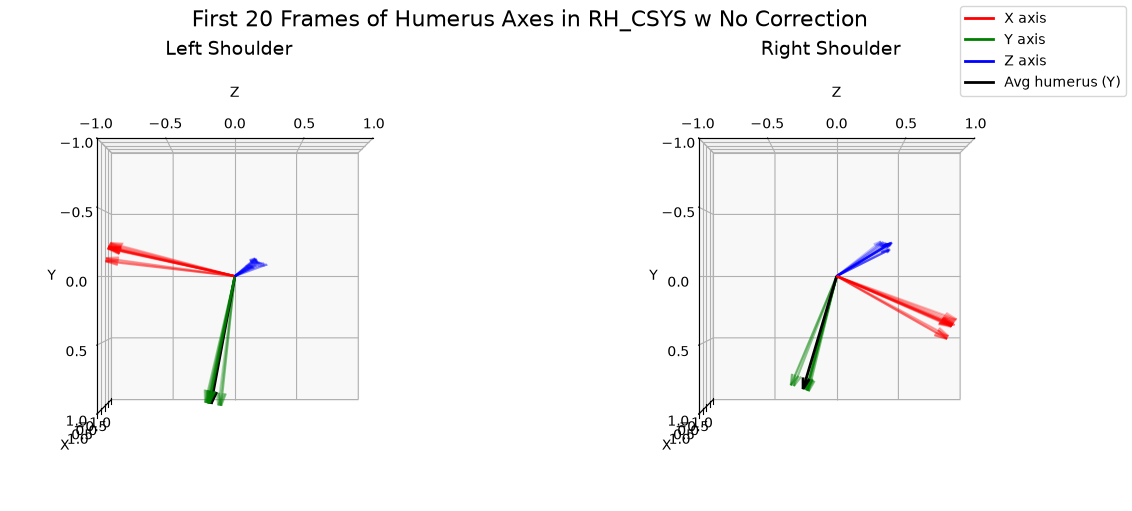

In [3]:
fig = plt.figure(figsize=(12, 5), layout="constrained")
n_frames = 20  # Number of frames to plot for each participant

R_right = create_rotation_matrices(data, 'right')[:n_frames]
R_left = create_rotation_matrices(data, 'left')[:n_frames]

avg_right = R_right[:, :, 1].mean(axis=0)  # Average humerus direction (Y-axis) for right shoulder
avg_left = R_left[:, :, 1].mean(axis=0)  # Average humerus direction (Y-axis) for left shoulder

for col_idx, (name, R) in enumerate([
    ("Left Shoulder", R_left),
    ("Right Shoulder", R_right),
]):

    ax = fig.add_subplot(
        1,
        2,
        col_idx + 1,
        projection="3d",
    )

    for r in R:
        # Local ISB axes
        x = r[:, 0]
        y = r[:, 1]
        z = r[:, 2]

        # Plot triad
        ax.quiver(0, 0, 0, *x, color="r", alpha=0.25, arrow_length_ratio=0.1)
        ax.quiver(0, 0, 0, *y, color="g", alpha=0.25, arrow_length_ratio=0.1)
        ax.quiver(0, 0, 0, *z, color="b", alpha=0.25, arrow_length_ratio=0.1)

    # Plot humerus direction
    if col_idx == 0:
        avg_humerus = avg_left
    else:
        avg_humerus = avg_right
    ax.quiver(
        0, 0, 0,
        *avg_humerus,
        color="black",
        alpha=1,
        linewidth=2,
        arrow_length_ratio=0.1,
    )

    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.set_zlim([-1, 1])

    ax.set_xticks([-1, -0.5, 0, 0.5, 1]) 
    ax.set_yticks([-1, -0.5, 0, 0.5, 1]) 
    ax.set_zticks([-1, -0.5, 0, 0.5, 1]) 

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

    ax.set_box_aspect([1, 1, 1])

    # Match ISB right humerothoracic view
    ax.view_init(
        elev=0,
        azim=0,
        roll=-90,
    )

    ax.set_title(name, fontsize=14)

handles = [
    plt.Line2D([0], [0], color="r", lw=2, label="X axis"),
    plt.Line2D([0], [0], color="g", lw=2, label="Y axis"),
    plt.Line2D([0], [0], color="b", lw=2, label="Z axis"),
    plt.Line2D([0], [0], color="black", lw=2, label="Avg humerus (Y)"),
]

fig.suptitle(f"First {n_frames} Frames of Humerus Axes in RH_CSYS w No Correction", fontsize=16)
fig.legend(
    handles=handles,
    loc="upper right",
)
plt.show()

Ok, so we're slightly off axis. Let's calculate the R matrix 

In [4]:
def get_correction_matrix(
    m: np.ndarray,
    target: np.ndarray = np.array([[1, 0, 0],[0, 1, 0],[0, 0, 1]])
):
    """
    Return a rotation matrix that rotates a matrix to align with the specified target matrix (default is the origin axes).

    Args:
        m (np.ndarray): A 3D matrix to be rotated.
        target (np.ndarray): The target matrix to align with (default is the origin axes).

    Returns:
        np.ndarray: A 3x3 rotation matrix that rotates m to align with the target matrix.
    """

    # ensure normalized matrix
    m = m / np.linalg.norm(m)
    target = target / np.linalg.norm(target)

    rot, _ = Rotation.align_vectors(m, target) #type: ignore
    return rot.as_matrix()


In [5]:
def apply_axis_orientation_correction(
    data: np.ndarray, 
    n_frames: int = 20
) -> np.ndarray:
    """
    Apply axis orientation correction to the given data.

    This function applies a correction matrix to the input data to align it with the specified target orientation.

    Args:
        data (np.ndarray): A 3D array of shape (n_frames, 3, 3) representing the rotation matrices for each frame.
        n_frames (int): The number of frames to use for calculating the average humerus direction.

    Returns:
        np.ndarray: The corrected data in the form of a 3D array of shape (n_frames, 3, 3) after applying the correction matrix.
    """
    # get the avg humerus direction for the first n_frames
    avg_hum_direction = data[:n_frames, :, :].mean(axis=0)

    # create correction matrix
    R_correction = get_correction_matrix(avg_hum_direction)

    # Apply correction to every frame
    return R_correction @ data  # NOTE: This order matters!! Don't rearrange!!

In [6]:
# Uncorrected rotation matrices
R_right = create_rotation_matrices(data, "right")[:n_frames]
R_left = create_rotation_matrices(data, "left")[:n_frames]

# Apply correction to every frame
R_right_corrected = apply_axis_orientation_correction(R_right)
R_left_corrected = apply_axis_orientation_correction(R_left)

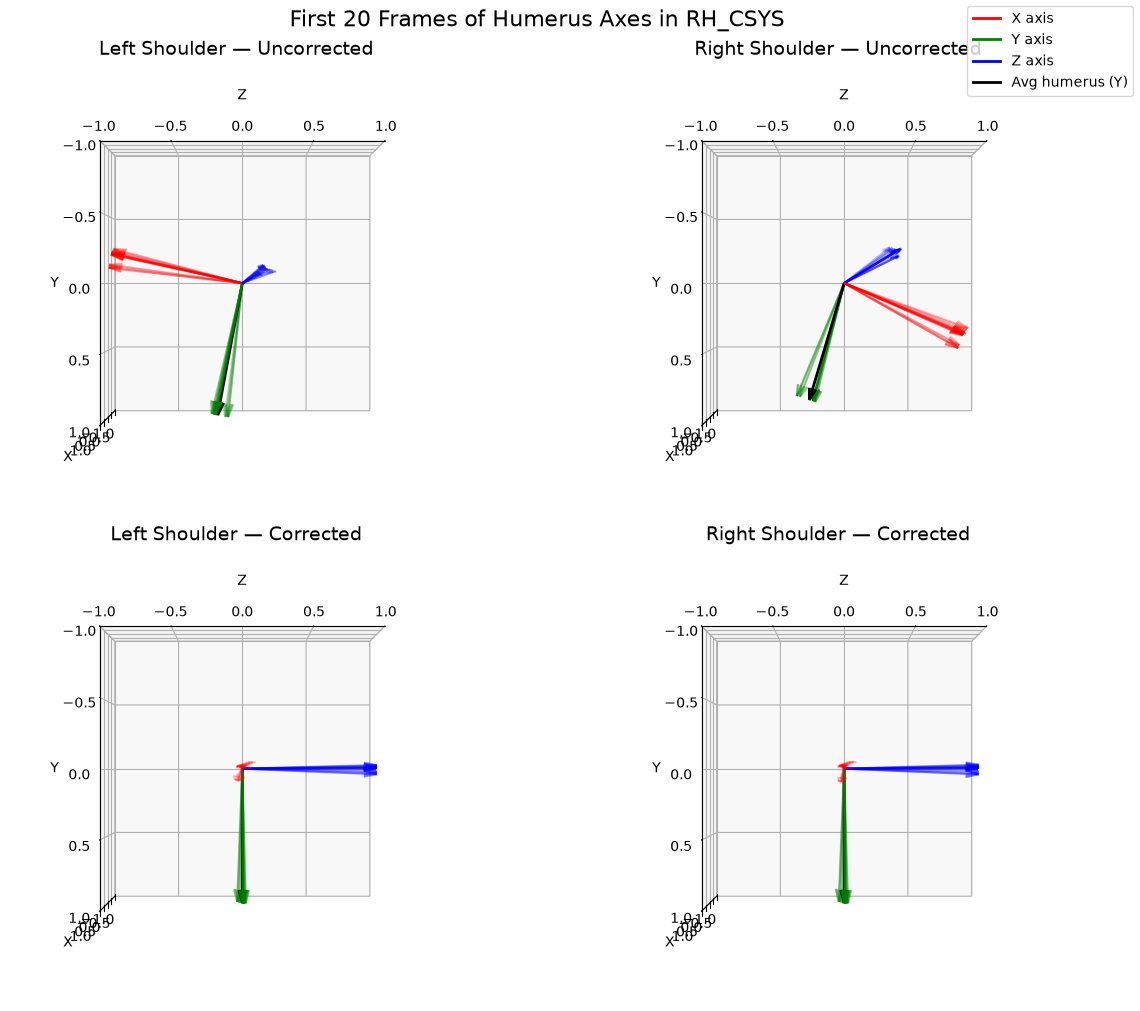

In [7]:
fig = plt.figure(figsize=(12, 10), layout="constrained")

data_sets = [
    ("Uncorrected", R_left, R_right),
    ("Corrected", R_left_corrected, R_right_corrected),
]

for row_idx, (row_title, R_left, R_right) in enumerate(data_sets):
    for col_idx, (name, R) in enumerate([
        ("Left Shoulder", R_left),
        ("Right Shoulder", R_right),
    ]):

        ax = fig.add_subplot(
            2,
            2,
            row_idx * 2 + col_idx + 1,
            projection="3d",
        )

        # Average humerus direction
        avg_humerus = R[:, :, 1].mean(axis=0)

        for r in R:
            # Local ISB axes
            x = r[:, 0]
            y = r[:, 1]
            z = r[:, 2]

            # Plot triad
            ax.quiver(
                0, 0, 0, *x,
                color="r",
                alpha=0.25,
                arrow_length_ratio=0.1,
            )
            ax.quiver(
                0, 0, 0, *y,
                color="g",
                alpha=0.25,
                arrow_length_ratio=0.1,
            )
            ax.quiver(
                0, 0, 0, *z,
                color="b",
                alpha=0.25,
                arrow_length_ratio=0.1,
            )

        # Plot average humerus direction
        ax.quiver(
            0, 0, 0,
            *avg_humerus,
            color="black",
            alpha=1,
            linewidth=2,
            arrow_length_ratio=0.1,
        )

        ax.set_xlim([-1, 1])
        ax.set_ylim([-1, 1])
        ax.set_zlim([-1, 1])

        ax.set_xticks([-1, -0.5, 0, 0.5, 1])
        ax.set_yticks([-1, -0.5, 0, 0.5, 1])
        ax.set_zticks([-1, -0.5, 0, 0.5, 1])

        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")

        ax.set_box_aspect([1, 1, 1])

        # Match ISB right humerothoracic view
        ax.view_init(
            elev=0,
            azim=0,
            roll=-90,
        )

        ax.set_title(f"{name} — {row_title}", fontsize=14)

handles = [
    plt.Line2D([0], [0], color="r", lw=2, label="X axis"),
    plt.Line2D([0], [0], color="g", lw=2, label="Y axis"),
    plt.Line2D([0], [0], color="b", lw=2, label="Z axis"),
    plt.Line2D([0], [0], color="black", lw=2, label="Avg humerus (Y)"),
]

fig.suptitle(
    f"First {n_frames} Frames of Humerus Axes in RH_CSYS",
    fontsize=16,
)

fig.legend(
    handles=handles,
    loc="upper right",
)

plt.show()

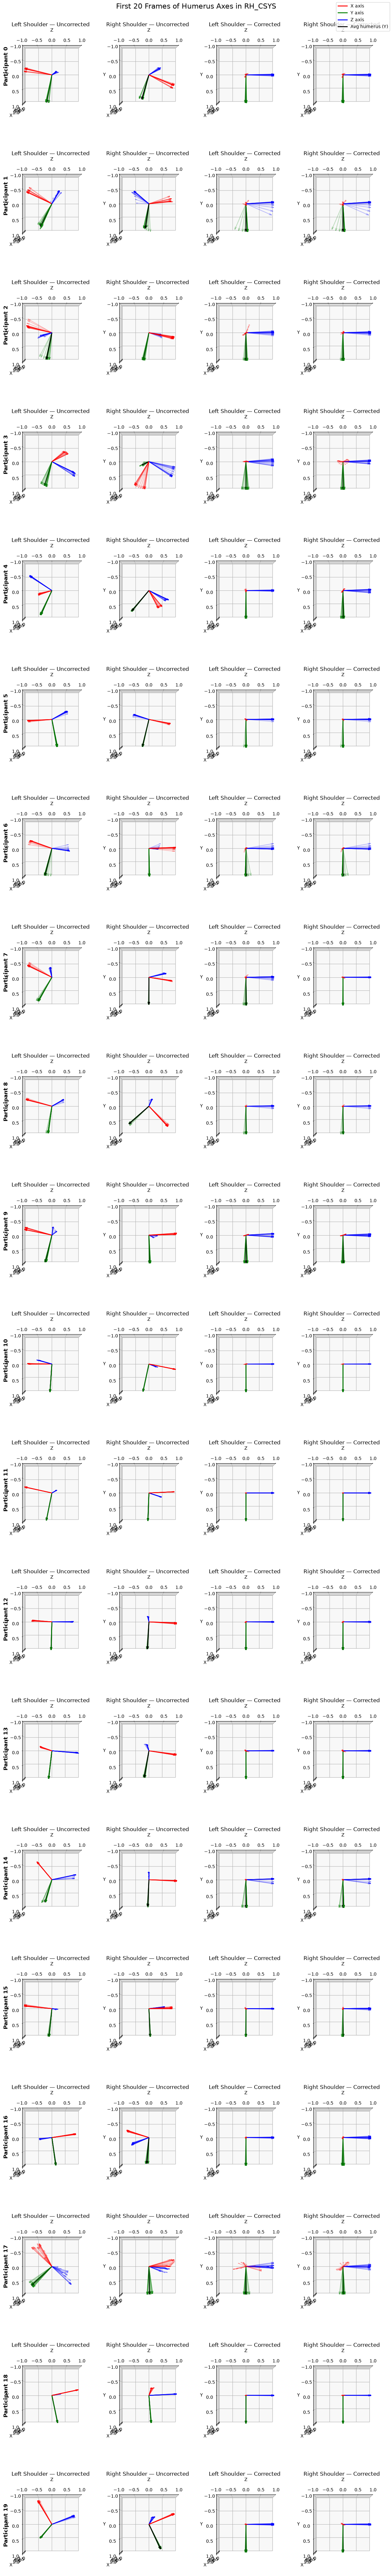

In [10]:
# Now let's apply this algorithm to every participant in the dataset and visualize the results.
n_frames = 20

fig = plt.figure(
    figsize=(12, 4 * len(participant_details)),
    layout="constrained",
)

for row_idx, participant in enumerate(participant_details):

    # ------------------------------------------------------------------
    # Get rotation matrices for this participant
    # ------------------------------------------------------------------
    data = load_motion_capture_data(participant.filename)
    
    R_left = create_rotation_matrices(data, "left")[:n_frames]
    R_right = create_rotation_matrices(data, "right")[:n_frames]

    # Apply correction to every frame
    R_left_corrected = apply_axis_orientation_correction(R_left)
    R_right_corrected = apply_axis_orientation_correction(R_right)

    # ------------------------------------------------------------------
    # Four columns:
    #   0 = uncorrected left
    #   1 = uncorrected right
    #   2 = corrected left
    #   3 = corrected right
    # ------------------------------------------------------------------

    data_sets = [
        ("Left Shoulder — Uncorrected", R_left),
        ("Right Shoulder — Uncorrected", R_right),
        ("Left Shoulder — Corrected", R_left_corrected),
        ("Right Shoulder — Corrected", R_right_corrected),
    ]

    for col_idx, (title, R) in enumerate(data_sets):

        ax = fig.add_subplot(
            len(participant_details),
            4,
            row_idx * 4 + col_idx + 1,
            projection="3d",
        )

        # Average humerus direction
        avg_humerus = R[:, :, 1].mean(axis=0)

        # Plot each frame
        for r in R:
            x = r[:, 0]
            y = r[:, 1]
            z = r[:, 2]

            ax.quiver(
                0, 0, 0, *x,
                color="r",
                alpha=0.25,
                arrow_length_ratio=0.1,
            )
            ax.quiver(
                0, 0, 0, *y,
                color="g",
                alpha=0.25,
                arrow_length_ratio=0.1,
            )
            ax.quiver(
                0, 0, 0, *z,
                color="b",
                alpha=0.25,
                arrow_length_ratio=0.1,
            )

        # Average humerus direction
        ax.quiver(
            0, 0, 0,
            *avg_humerus,
            color="black",
            alpha=1,
            linewidth=2,
            arrow_length_ratio=0.1,
        )

        # Axes
        ax.set_xlim([-1, 1])
        ax.set_ylim([-1, 1])
        ax.set_zlim([-1, 1])

        ax.set_xticks([-1, -0.5, 0, 0.5, 1])
        ax.set_yticks([-1, -0.5, 0, 0.5, 1])
        ax.set_zticks([-1, -0.5, 0, 0.5, 1])

        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")

        ax.set_box_aspect([1, 1, 1])

        # Match ISB right humerothoracic view
        ax.view_init(
            elev=0,
            azim=0,
            roll=-90,
        )

        ax.set_title(title, fontsize=12)

    # Label each participant's row
    # Assumes participant has a `participant_id` attribute.
    fig.text(
        0.01,
        1 - (row_idx + 0.5) / len(participant_details),
        str(f"Participant {row_idx}"),
        rotation=90,
        va="center",
        ha="center",
        fontsize=12,
        fontweight="bold",
    )


handles = [
    plt.Line2D([0], [0], color="r", lw=2, label="X axis"),
    plt.Line2D([0], [0], color="g", lw=2, label="Y axis"),
    plt.Line2D([0], [0], color="b", lw=2, label="Z axis"),
    plt.Line2D([0], [0], color="black", lw=2, label="Avg humerus (Y)"),
]

fig.suptitle(
    f"First {n_frames} Frames of Humerus Axes in RH_CSYS",
    fontsize=16,
)

fig.legend(
    handles=handles,
    loc="upper right",
)

plt.show()

Let me just check what direction the X axis is pointing

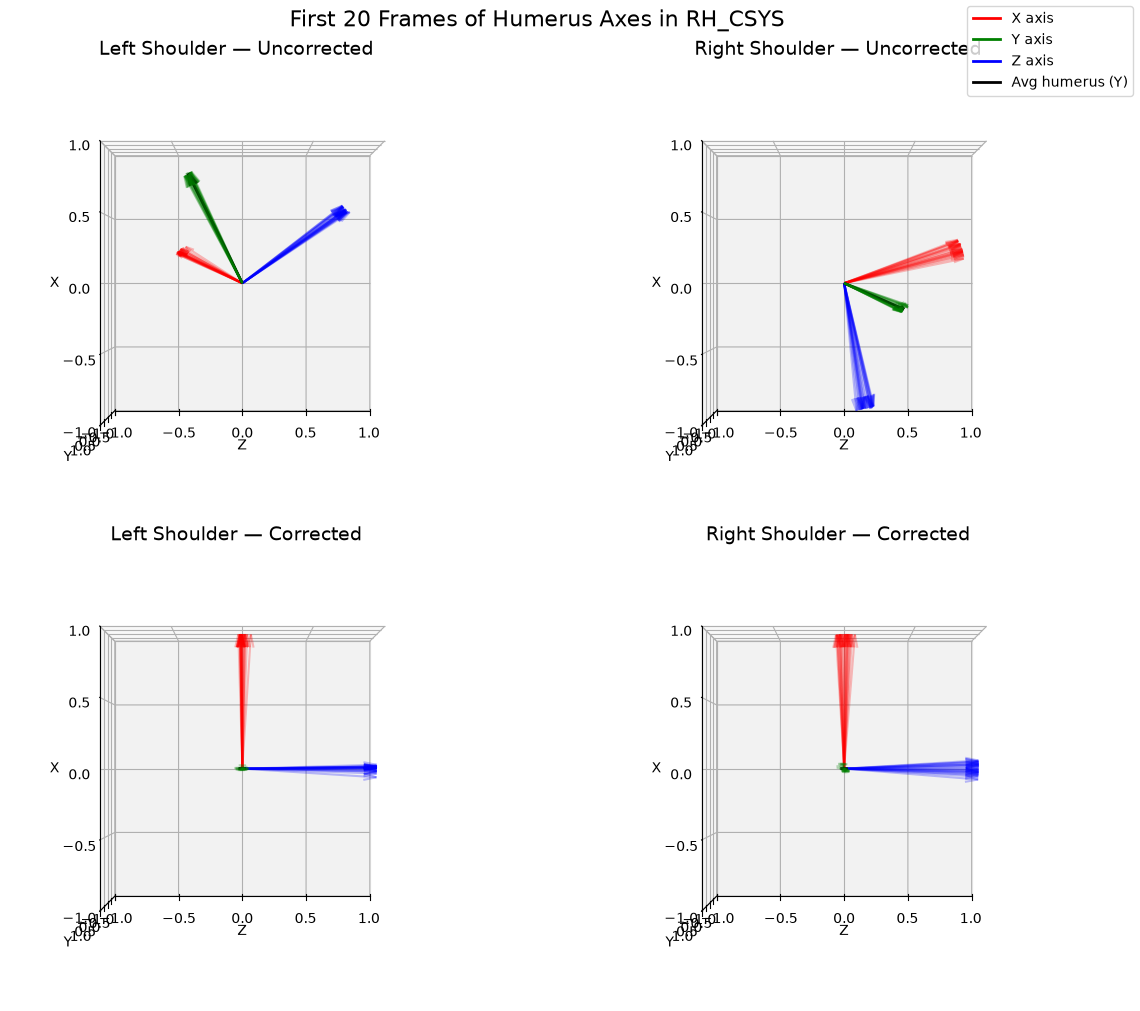

In [11]:
data = load_motion_capture_data(participant.filename)

R_left = create_rotation_matrices(data, "left")[:n_frames]
R_right = create_rotation_matrices(data, "right")[:n_frames]

# Average humerus directions
avg_left = R_left.mean(axis=0)
avg_right = R_right.mean(axis=0)

# Correction matrices based on the average humerus direction
correction_left = get_correction_matrix(avg_left)
correction_right = get_correction_matrix(avg_right)

# Apply correction to every frame
R_left_corrected = correction_left @ R_left
R_right_corrected = correction_right @ R_right

fig = plt.figure(figsize=(12, 10), layout="constrained")

data_sets = [
    ("Uncorrected", R_left, R_right),
    ("Corrected", R_left_corrected, R_right_corrected),
]

for row_idx, (row_title, R_left, R_right) in enumerate(data_sets):
    for col_idx, (name, R) in enumerate([
        ("Left Shoulder", R_left),
        ("Right Shoulder", R_right),
    ]):

        ax = fig.add_subplot(
            2,
            2,
            row_idx * 2 + col_idx + 1,
            projection="3d",
        )

        # Average humerus direction
        avg_humerus = R[:, :, 1].mean(axis=0)

        for r in R:
            # Local ISB axes
            x = r[:, 0]
            y = r[:, 1]
            z = r[:, 2]

            # Plot triad
            ax.quiver(
                0, 0, 0, *x,
                color="r",
                alpha=0.25,
                arrow_length_ratio=0.1,
            )
            ax.quiver(
                0, 0, 0, *y,
                color="g",
                alpha=0.25,
                arrow_length_ratio=0.1,
            )
            ax.quiver(
                0, 0, 0, *z,
                color="b",
                alpha=0.25,
                arrow_length_ratio=0.1,
            )

        # Plot average humerus direction
        ax.quiver(
            0, 0, 0,
            *avg_humerus,
            color="black",
            alpha=1,
            linewidth=2,
            arrow_length_ratio=0.1,
        )

        ax.set_xlim([-1, 1])
        ax.set_ylim([-1, 1])
        ax.set_zlim([-1, 1])

        ax.set_xticks([-1, -0.5, 0, 0.5, 1])
        ax.set_yticks([-1, -0.5, 0, 0.5, 1])
        ax.set_zticks([-1, -0.5, 0, 0.5, 1])

        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")

        ax.set_box_aspect([1, 1, 1])

        # Match ISB right humerothoracic view
        ax.view_init(
            elev=0,
            azim=90,
            roll=-90,
        )

        ax.set_title(f"{name} — {row_title}", fontsize=14)

handles = [
    plt.Line2D([0], [0], color="r", lw=2, label="X axis"),
    plt.Line2D([0], [0], color="g", lw=2, label="Y axis"),
    plt.Line2D([0], [0], color="b", lw=2, label="Z axis"),
    plt.Line2D([0], [0], color="black", lw=2, label="Avg humerus (Y)"),
]

fig.suptitle(
    f"First {n_frames} Frames of Humerus Axes in RH_CSYS",
    fontsize=16,
)

fig.legend(
    handles=handles,
    loc="upper right",
)

plt.show()

Nice! 

After this transformation, all arms will be:
1. put into the ISB right humerus coordinate system (easier for analysis)
2. corrected such that their arms started in tin soldier position.